# K-nearest neighbours (KNN)

**UWE Bristol · Introduction to Machine Learning**

This notebook walks through one classification model from start to finish: **KNN**.

You will see:

1. how the model works, in plain language;
2. how to load, explore and prepare a dataset (pre-processing);
3. why we split the data into a training set and a test set;
4. how to train (fit) the model and make predictions;
5. how to measure performance with accuracy, a confusion matrix, precision, recall, F1 and a ROC curve;
6. how to visualise what the model has learned;
7. what happens when you change the model's settings.

No previous experience with the model is assumed. Run each cell in order with **Shift + Enter**, and
read the text above each cell before you run it.

## 1. How KNN works

### The idea

KNN is based on a very simple idea: **things that are similar tend to belong to the same group.**

Imagine you find a bird in the garden and want to know what it is. You flick through a guidebook and
find the five birds that look most like yours. If four of them are sparrows, you would probably decide
yours is a sparrow too. That is exactly what KNN does.

### The steps

To classify a new tumour, KNN:

1. measures the **distance** between the new tumour and every tumour in the training set, using all of
   the features (usually straight-line distance, called Euclidean distance);
2. picks the **k** closest ones: the nearest neighbours;
3. lets them **vote**. The most common class among the neighbours is the prediction.

KNN does not build a formula or a set of rules during training. It simply stores the training data and
does all its work when a prediction is needed. This is why it is sometimes called a **lazy learner**.

### A picture of the idea

The chart below uses made-up points. The star is a new example. Its 5 nearest neighbours are joined to
it with lines: 4 are orange triangles and 1 is a blue circle, so KNN would predict "orange triangle".

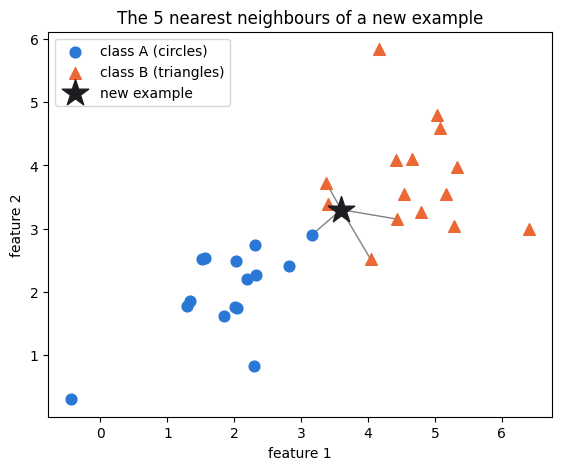

Votes from the 5 neighbours: ['B', 'B', 'A', 'B', 'B']


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
blue = rng.normal([2, 2], 0.9, size=(15, 2))
orange = rng.normal([4.5, 4], 0.9, size=(15, 2))
new_point = np.array([3.6, 3.3])

points = np.vstack([blue, orange])
labels = np.array([0] * 15 + [1] * 15)
distances = np.sqrt(((points - new_point) ** 2).sum(axis=1))
nearest = np.argsort(distances)[:5]

plt.figure(figsize=(6.5, 5))
for i in nearest:
    plt.plot([new_point[0], points[i, 0]], [new_point[1], points[i, 1]], color="grey", lw=1, zorder=1)
plt.scatter(blue[:, 0], blue[:, 1], color="#2a78d6", s=60, label="class A (circles)", zorder=2)
plt.scatter(orange[:, 0], orange[:, 1], color="#eb6834", marker="^", s=70, label="class B (triangles)", zorder=2)
plt.scatter(*new_point, marker="*", s=400, color="#1D1C21", label="new example", zorder=3)
plt.title("The 5 nearest neighbours of a new example")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend(loc="upper left")
plt.show()

print("Votes from the 5 neighbours:", ["B" if labels[i] else "A" for i in nearest])

### Choosing k

The number of neighbours, **k**, is the main setting:

- a **small k** (for example 1) listens to a single neighbour, so one unusual tumour can change the
  answer. The model follows the training data too closely: **overfitting**;
- a **large k** averages over many tumours, so local detail is lost. Taken to the extreme, it just
  predicts the most common class every time: **underfitting**.

An odd value of k is often used for two classes, so the vote cannot be tied.

### Why distance means scaling matters

Because KNN measures distance across all features at once, a feature measured in large numbers (like
area, in the hundreds) would swamp a feature measured in small numbers (like smoothness, around 0.1).
We will see this in action later.

## Setting up

First we import the libraries we need. Each line has a comment saying what it is for.

In [2]:
# pandas holds data in tables (DataFrames); numpy does the number crunching
import pandas as pd
import numpy as np
# matplotlib draws our charts
import matplotlib.pyplot as plt

# The dataset, and tools for splitting and scaling it
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Performance measures and chart helpers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)
from sklearn.inspection import DecisionBoundaryDisplay

# The model for this notebook
from sklearn.neighbors import KNeighborsClassifier

# Chart settings and colours used throughout
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BENIGN_COLOUR = "#2a78d6"      # blue
MALIGNANT_COLOUR = "#eb6834"   # orange
TRAIN_COLOUR = "#1D1C21"       # dark grey
CHECK_COLOUR = "#2a78d6"       # blue

## 2. The dataset

We use the **Breast Cancer Wisconsin** dataset, which comes built into scikit-learn, so there is
nothing to download. Each row is one breast tumour. The columns are measurements taken from a
microscope image of cells from the tumour, such as the radius of the cell nuclei, their texture
(how varied the grey levels are) and how many concave points (inward dents) their outlines have.

Our job is to predict whether each tumour is **malignant** (cancerous) or **benign** (not cancerous).
There are only two possible answers, so this is a **binary classification** problem.

In [3]:
# Load the data as a pandas DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Number of tumours (rows):", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of tumours (rows): 569
Number of columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


There are 569 tumours and 31 columns: 30 measurements, which are the **features** (the inputs), and
a column called `target`, which is the **label** (the answer we want to predict).

The 30 features are really 10 measurements, each recorded in three ways: the `mean` across the cells
in the image, the `error` (how much the values varied) and the `worst` (the average of the three
largest values).

## 3. Exploring the data

Before building any model it is worth looking at the data. We want to know how many examples there
are of each class and whether the features look useful.

### Fixing the label

In this dataset `target` is **0 for malignant and 1 for benign**, which is the opposite of what most
people would expect. scikit-learn treats the class labelled 1 as the "positive" class when it calculates
precision and recall, and we care most about finding malignant tumours. So we make a new, clearer
label column where **1 means malignant** and **0 means benign**.

malignant
benign (0)       357
malignant (1)    212
Name: count, dtype: int64


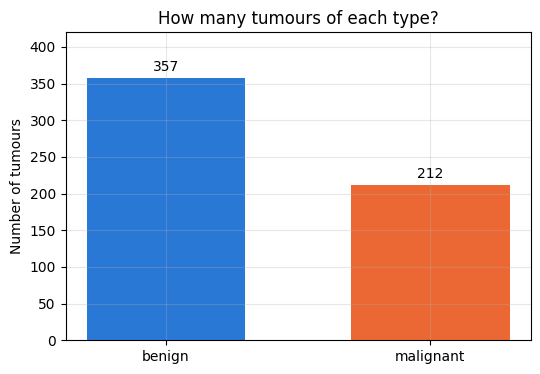

In [4]:
# New label: 1 = malignant, 0 = benign
df["malignant"] = (df["target"] == 0).astype(int)
df = df.drop(columns="target")

counts = df["malignant"].value_counts().sort_index()
print(counts.rename({0: "benign (0)", 1: "malignant (1)"}))

plt.figure(figsize=(6, 4))
bars = plt.bar(["benign", "malignant"], counts.values, color=[BENIGN_COLOUR, MALIGNANT_COLOUR], width=0.6)
plt.bar_label(bars, padding=3)
plt.ylabel("Number of tumours")
plt.title("How many tumours of each type?")
plt.ylim(0, 420)
plt.show()

There are 357 benign and 212 malignant tumours, so about 63% are benign. The classes are not
perfectly balanced. This gives us a useful **baseline**: a lazy "model" that always says benign would
be right about 63% of the time. Any real model has to do a lot better than that to be worth using.

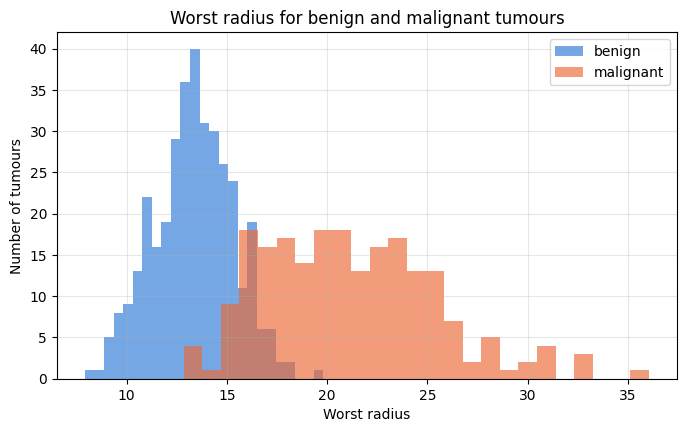

In [5]:
# Does one feature on its own separate the two classes?
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df["malignant"] == 0, "worst radius"], bins=25, alpha=0.65,
         color=BENIGN_COLOUR, label="benign")
plt.hist(df.loc[df["malignant"] == 1, "worst radius"], bins=25, alpha=0.65,
         color=MALIGNANT_COLOUR, label="malignant")
plt.xlabel("Worst radius")
plt.ylabel("Number of tumours")
plt.title("Worst radius for benign and malignant tumours")
plt.legend()
plt.show()

Malignant tumours tend to have larger cells, but the two groups overlap in the middle. No single
measurement separates them perfectly, which is why we want a model that combines all 30.

## 4. Data pre-processing

Pre-processing means checking and preparing the data so that a model can learn from it properly.

### 4.1 Missing values and duplicates

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


This dataset has no missing values and no duplicated rows, which is unusual. With real-world data you
would normally need to deal with gaps, for example by removing incomplete rows or filling each gap
with the column's median value.

### 4.2 Separating the features (X) and the label (y)

By convention we call the inputs `X` and the answers `y`.

In [7]:
X = df.drop(columns="malignant")   # the 30 measurements
y = df["malignant"]                 # the answer: 1 = malignant, 0 = benign

print("X:", X.shape, "   y:", y.shape)

X: (569, 30)    y: (569,)


### 4.3 Do the features need scaling?

The features are measured on very different scales:

In [8]:
X[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean", "min", "max"]].round(3)

,mean radius,mean area,mean smoothness
mean,14.127,654.889,0.096
min,6.981,143.500,0.053
max,28.110,2501.000,0.163


`mean area` is in the hundreds, while `mean smoothness` is around 0.1. For this model that is a
problem. KNN works out distances between tumours. A difference of 100 in area would count far more than a difference of 0.05 in smoothness, simply because the numbers are bigger, even if smoothness were the more useful measurement.

The fix is **standardisation** with `StandardScaler`. It rescales every feature so that its average is 0
and its standard deviation is 1, putting all 30 features on the same footing. We will do this in the
next section, **after** splitting the data, for a reason explained there.

## 5. The train/test split

If we trained a model on every tumour and then tested it on the same tumours, it could score well just
by remembering them. That would tell us nothing about how it will perform on **new** patients.

So we split the data into two parts:

- the **training set**, which the model learns from, and
- the **test set**, which we hide away and only use at the end to check how well the model works on
  tumours it has never seen.

The settings we use:

- `test_size=0.25`: keep 25% of the tumours for testing.
- `stratify=y`: keep the same proportion of malignant tumours in both parts.
- `random_state=42`: the split is random, but fixing this number means you get the same split every
  time you run the notebook (and the same as everyone else in the class).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Training set:", len(X_train), "tumours")
print("Test set:    ", len(X_test), "tumours")
print("Malignant in training set:", round(y_train.mean() * 100, 1), "%")
print("Malignant in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set: 426 tumours
Test set:     143 tumours
Malignant in training set: 37.3 %
Malignant in test set:     37.1 %


Thanks to `stratify=y`, both sets contain the same share of malignant tumours (about 37%).

### Scaling, after the split

Now we scale. There is one rule that matters a lot: the scaler must **learn only from the training
set**. It works out each feature's mean and standard deviation from the training data, and then uses
those same numbers to transform the test data.

If we scaled before splitting, the scaler would have seen the test tumours, and a little information
about the test set would leak into training. This is called **data leakage**, and it makes results
look slightly better than they really are.

In [10]:
scaler = StandardScaler()

# Learn the mean and standard deviation from the training set, then apply them
X_train_ready = scaler.fit_transform(X_train)

# Apply the SAME transformation to the test set (no fitting here)
X_test_ready = scaler.transform(X_test)

print("Mean area before scaling (training set):", round(X_train["mean area"].mean(), 1))
col = list(X.columns).index("mean area")
print("Mean area after scaling (training set): ", round(X_train_ready[:, col].mean(), 3))
print("Standard deviation after scaling:       ", round(X_train_ready[:, col].std(), 3))

Mean area before scaling (training set): 660.1
Mean area after scaling (training set):  0.0
Standard deviation after scaling:        1.0


## 6. Fitting (training) the model


We create the model with k = 5 and call `fit` on the training data.

For KNN, "fitting" is almost instant: the model simply stores the 426 training tumours so it can
compare new tumours with them later.

In [11]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_ready, y_train)

print("Number of training tumours stored:", model.n_samples_fit_)

Number of training tumours stored: 426


### Watching KNN make one decision

Let's look at the first tumour in the test set and find its 5 nearest neighbours in the training set.

In [12]:
distances, indices = model.kneighbors(X_test_ready[:1])

neighbours = pd.DataFrame({
    "distance": distances[0].round(2),
    "neighbour's label": ["malignant" if v == 1 else "benign" for v in y_train.iloc[indices[0]]],
})
print(neighbours)
print()
print("Prediction for this tumour:", "malignant" if model.predict(X_test_ready[:1])[0] == 1 else "benign")
print("What it really is:          ", "malignant" if y_test.iloc[0] == 1 else "benign")

   distance neighbour's label
0      6.98         malignant
1      7.05         malignant
2      7.11         malignant
3      7.51         malignant
4      7.56         malignant

Prediction for this tumour: malignant
What it really is:           malignant


The prediction is simply the majority label among these five neighbours.

## 7. Making predictions

With the model trained, we ask it to predict the label for every tumour in the **test set**. These are
tumours it has never seen.

As well as a yes/no answer, `predict_proba` gives the model's estimated **probability** that each
tumour is malignant. By default, the model predicts malignant when that probability is 0.5 or more.

In [13]:
y_pred = model.predict(X_test_ready)
y_prob = model.predict_proba(X_test_ready)[:, 1]   # probability of malignant

# Compare the first 10 predictions with the real answers
first_ten = pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted": y_pred[:10],
    "probability of malignant": y_prob[:10].round(3),
})
first_ten["correct?"] = np.where(first_ten["actual"] == first_ten["predicted"], "yes", "NO")
first_ten

,actual,predicted,probability of malignant,correct?
0,1,1,1.0,yes
1,0,0,0.0,yes
2,1,1,1.0,yes
3,0,0,0.0,yes
4,0,0,0.0,yes
5,0,0,0.0,yes
6,0,0,0.0,yes
7,0,0,0.0,yes
8,0,0,0.0,yes
9,0,0,0.0,yes


## 8. Measuring performance

There are several ways to measure how good a classifier is. Each one answers a slightly different
question, and for a medical problem like this the differences really matter.

### 8.1 Accuracy

Accuracy is the simplest measure: **what fraction of predictions were correct?**

In [14]:
accuracy = accuracy_score(y_test, y_pred)
baseline = (y_test == 0).mean()   # always guessing "benign"

print(f"Accuracy of the model:          {accuracy:.3f}")
print(f"Accuracy of always saying benign: {baseline:.3f}")

Accuracy of the model:          0.958
Accuracy of always saying benign: 0.629


The model is well above the baseline. But accuracy on its own hides an important detail: **what kind
of mistakes** did the model make?

### 8.2 The confusion matrix

A confusion matrix sorts every prediction into one of four boxes:

| | Model says benign | Model says malignant |
|---|---|---|
| **Really benign** | True negative (TN): correct | False positive (FP): a false alarm |
| **Really malignant** | False negative (FN): a missed cancer | True positive (TP): correct |

The two kinds of mistake are not equally bad. A false alarm means a worried patient and an extra test.
A false negative means a cancer is missed.

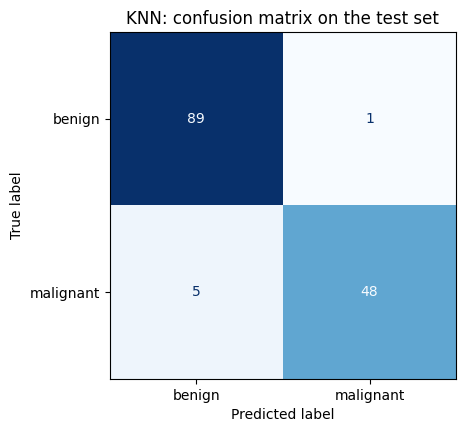

True negatives  (benign, correctly identified):    89
False positives (benign, wrongly called malignant): 1
False negatives (malignant, missed):               5
True positives  (malignant, correctly found):      48


In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False
)
plt.title("KNN: confusion matrix on the test set")
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True negatives  (benign, correctly identified):    {tn}")
print(f"False positives (benign, wrongly called malignant): {fp}")
print(f"False negatives (malignant, missed):               {fn}")
print(f"True positives  (malignant, correctly found):      {tp}")

### 8.3 Precision, recall and F1

These three measures focus on the malignant class:

- **Precision** = TP / (TP + FP). Of all the tumours the model *called* malignant, what fraction really
  were? High precision means few false alarms.
- **Recall** = TP / (TP + FN). Of all the tumours that *really were* malignant, what fraction did the
  model find? High recall means few missed cancers. (Recall is also called **sensitivity**.)
- **F1 score** combines precision and recall into one number. It is only high when both are high.

For cancer screening, recall is usually the most important of these, because missing a cancer is the
worst outcome.

In [16]:
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

Precision: 0.980
Recall:    0.906


F1 score:  0.941


`classification_report` prints all of these at once, for **both** classes. The `support` column is the
number of test tumours in each class.

In [17]:
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

              precision    recall  f1-score   support

      benign       0.95      0.99      0.97        90
   malignant       0.98      0.91      0.94        53

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



### 8.4 The ROC curve and AUC

The model's decision depends on the 0.5 probability threshold. If we lowered the threshold, it would
catch more malignant tumours but raise more false alarms; if we raised it, the opposite.

A **ROC curve** shows this trade-off across every possible threshold. It plots the **true positive
rate** (recall) against the **false positive rate** (the fraction of benign tumours wrongly flagged).
A perfect model goes straight up the left side and along the top. A model that guesses at random
follows the dashed diagonal line.

The **AUC** (area under the curve) sums this up in one number, from 0.5 (guessing) to 1.0 (perfect).

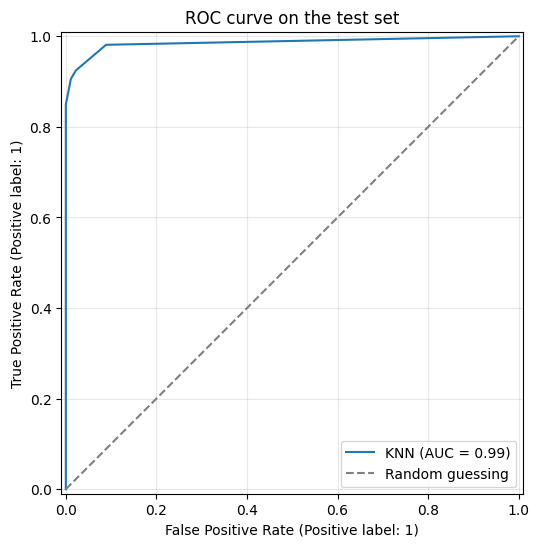

AUC: 0.986


In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, name="KNN", ax=ax)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
ax.set_title("ROC curve on the test set")
ax.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")

## 9. Looking inside the model

### What happens if we forget to scale?

We said KNN needs scaled data. Let's test that claim by training the same model on the original,
unscaled data.

In [19]:
unscaled_model = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

print(f"Accuracy WITHOUT scaling: {unscaled_model.score(X_test, y_test):.3f}")
print(f"Accuracy WITH scaling:    {model.score(X_test_ready, y_test):.3f}")

# Which features have the biggest ranges? These dominate the distance when unscaled.
ranges = (X_train.max() - X_train.min()).sort_values(ascending=False)
print("\nFeatures with the largest ranges:")
print(ranges.head(4).round(1))

Accuracy WITHOUT scaling: 0.923
Accuracy WITH scaling:    0.958

Features with the largest ranges:
worst area         4068.8
mean area          2357.5
area error          535.4
worst perimeter     200.8
dtype: float64


Without scaling, the distance is dominated by the area features, whose ranges are in the thousands.
The other features barely count. Scaling lets every feature contribute.

### How confident is the model?

For KNN, the "probability" is just the share of neighbours that voted malignant. With k = 5 it can only
be 0, 0.2, 0.4, 0.6, 0.8 or 1.

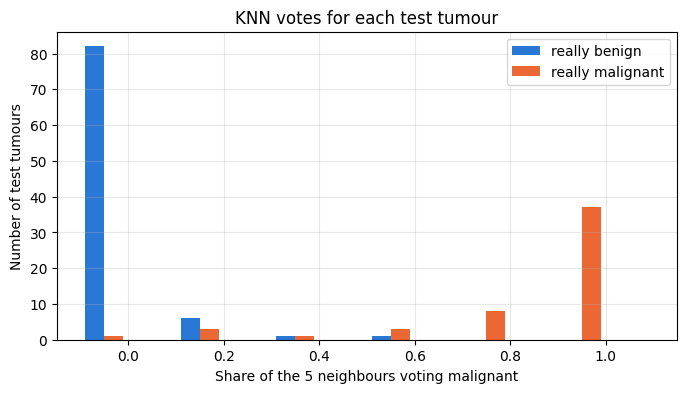

In [20]:
plt.figure(figsize=(8, 4))
plt.hist([y_prob[y_test == 0], y_prob[y_test == 1]], bins=np.linspace(-0.1, 1.1, 13),
         color=[BENIGN_COLOUR, MALIGNANT_COLOUR], label=["really benign", "really malignant"])
plt.xlabel("Share of the 5 neighbours voting malignant")
plt.ylabel("Number of test tumours")
plt.title("KNN votes for each test tumour")
plt.legend()
plt.show()

Most tumours get a unanimous vote (0 or 1). The mistakes tend to come from the split votes in the middle.

## 10. Seeing the decision boundary

With 30 features we cannot draw what the model has learned. But if we train the same kind of model on
just **two** features, we can plot every tumour on a flat chart and colour in the regions where the
model would predict benign or malignant. The line where the colours meet is the **decision boundary**.

We use `mean radius` and `mean texture`. These two features overlap quite a lot, which makes the
boundary more interesting to look at. This two-feature model is only for the picture; our real model
still uses all 30 features.

Because this model needs scaled data, we use `make_pipeline`, which bundles a scaler and the model
together so that scaling happens automatically, learned from the training data only.

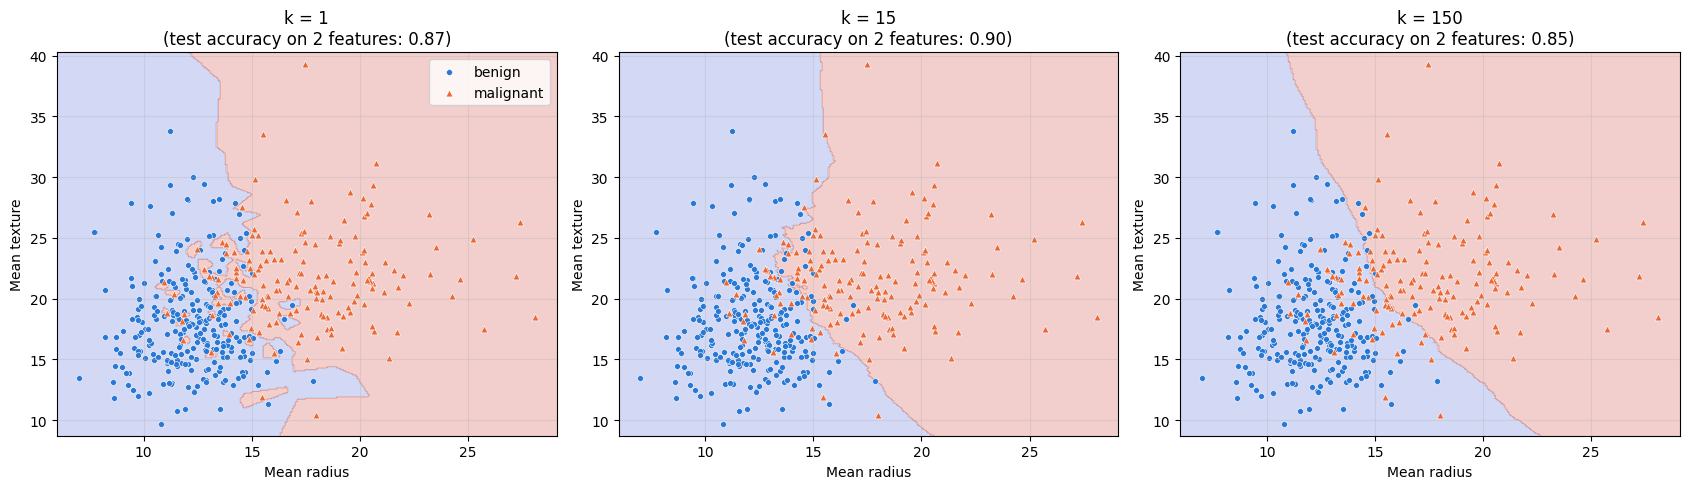

In [21]:
two = ["mean radius", "mean texture"]
X_two = X_train[two]

def draw_boundary(model, ax, title):
    """Fit a model on two features and colour in its predictions."""
    model.fit(X_two, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X_two, response_method="predict", ax=ax, alpha=0.25,
        cmap="coolwarm", grid_resolution=300, xlabel="Mean radius", ylabel="Mean texture"
    )
    benign = y_train == 0
    ax.scatter(X_two.loc[benign, two[0]], X_two.loc[benign, two[1]], s=18,
               color=BENIGN_COLOUR, edgecolor="white", linewidth=0.4, label="benign")
    ax.scatter(X_two.loc[~benign, two[0]], X_two.loc[~benign, two[1]], s=24, marker="^",
               color=MALIGNANT_COLOUR, edgecolor="white", linewidth=0.4, label="malignant")
    acc = model.score(X_test[two], y_test)
    ax.set_title(f"{title}\n(test accuracy on 2 features: {acc:.2f})")


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, k in zip(axes, [1, 15, 150]):
    draw_boundary(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)), ax, f"k = {k}")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Changing the parameters

Every model has settings that we choose before training. These are called **hyperparameters**.
Changing them changes how simple or complex the model is.

### Choosing settings fairly

We must **not** use the test set to choose settings. If we tried lots of settings and kept whichever
did best on the test set, the test set would no longer be a fair check.

Instead we use **cross-validation** on the training set. The training data is split into 5 parts. The
model trains on 4 parts and is checked on the 5th, and this is repeated so that each part gets a turn.
The average of the 5 scores tells us how well a setting works on data the model did not train on.

The function below tries a list of values for one setting and plots two lines:

- **training accuracy**: how well the model does on the data it learned from;
- **cross-validated accuracy**: our fair estimate of how it will do on new data.

A big gap between the two lines is a sign of **overfitting**: the model has memorised the training data.
When both lines are low, the model is **underfitting**: it is too simple to capture the pattern.

### The number of neighbours, k

We try k from very large (simple) to 1 (complex). We use `make_pipeline` so that, inside
cross-validation, the scaler is re-learned on each training fold and never sees the fold being checked.
That is why we pass the unscaled `X_train` here.

In [22]:
def try_settings(make_model, values, setting_name, X_data, log_scale=False, tolerance=0):
    """Try each value of one setting; plot training vs cross-validated accuracy.

    The values must be listed from simplest to most complex. The chosen value is the simplest
    one whose cross-validated accuracy is within `tolerance` of the best.
    """
    train_scores, cv_scores = [], []
    for value in values:
        m = make_model(value)
        cv_scores.append(cross_val_score(m, X_data, y_train, cv=5).mean())
        train_scores.append(m.fit(X_data, y_train).score(X_data, y_train))

    plt.plot(values, train_scores, "o-", color=TRAIN_COLOUR, label="Training accuracy")
    plt.plot(values, cv_scores, "s-", color=CHECK_COLOUR, label="Cross-validated accuracy")
    if log_scale:
        plt.xscale("log")
    plt.xlabel(setting_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    table = pd.DataFrame({setting_name: values,
                          "training accuracy": np.round(train_scores, 3),
                          "cross-validated accuracy": np.round(cv_scores, 3)})
    top = max(cv_scores)
    best = next(v for v, s in zip(values, cv_scores) if s >= top - tolerance - 1e-9)
    return table, best

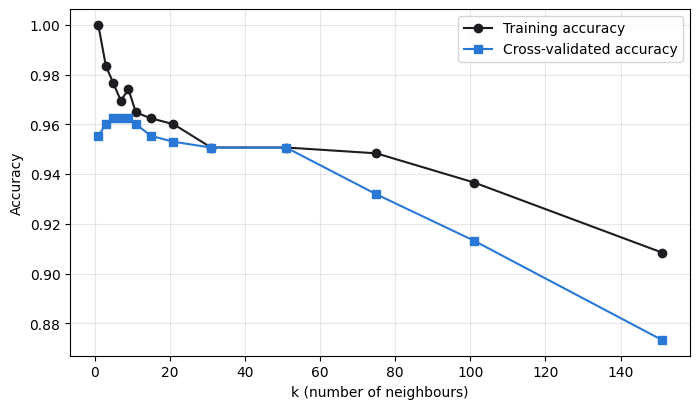

Chosen k: 9


,k (number of neighbours),training accuracy,cross-validated accuracy
0,151,0.908,0.873
1,101,0.937,0.913
2,75,0.948,0.932
3,51,0.951,0.951
4,31,0.951,0.951
5,21,0.960,0.953
6,15,0.962,0.955
7,11,0.965,0.960
8,9,0.974,0.962
9,7,0.969,0.962


In [23]:
k_values = [151, 101, 75, 51, 31, 21, 15, 11, 9, 7, 5, 3, 1]
table, best_k = try_settings(
    lambda k: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
    k_values, "k (number of neighbours)", X_train)
print("Chosen k:", best_k)
table

**What to notice:** at k = 1 the training accuracy is exactly 100%, because every training tumour's
nearest neighbour is itself. That score is meaningless, which is why we trust the cross-validated line
instead. At the other end, very large k values make both lines drop.

### Weighting the votes by distance

By default every neighbour gets an equal vote. With `weights="distance"`, closer neighbours count more.

In [24]:
for weights in ["uniform", "distance"]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k, weights=weights))
    score = cross_val_score(pipe, X_train, y_train, cv=5).mean()
    print(f"weights = {weights:>8}: cross-validated accuracy = {score:.3f}")

weights =  uniform: cross-validated accuracy = 0.962
weights = distance: cross-validated accuracy = 0.965


### Retraining with the chosen setting

Now we train a fresh model with the chosen setting on the whole training set, and check it **once** on
the test set. We compare it with the default model from earlier.

In [25]:
tuned = KNeighborsClassifier(n_neighbors=best_k)
tuned.fit(X_train_ready, y_train)
tuned_pred = tuned.predict(X_test_ready)

summary = pd.DataFrame({
    "default model": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                      recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "tuned model":   [accuracy_score(y_test, tuned_pred), precision_score(y_test, tuned_pred),
                      recall_score(y_test, tuned_pred), f1_score(y_test, tuned_pred)],
}, index=["accuracy", "precision", "recall", "F1"]).round(3)
summary

,default model,tuned model
accuracy,0.958,0.958
precision,0.980,0.980
recall,0.906,0.906
F1,0.941,0.941


Tuning does not always change the result. Sometimes the default settings are already a good choice, or
the chosen setting happens to make the same predictions on these 143 test tumours. Occasionally a tuned
model even does slightly worse on the test set, because cross-validation gives a fair **estimate**, not a
guarantee. What matters is that the setting was chosen without looking at the test set, so the test
score is an honest measure of how the model is likely to perform on new patients.

## 12. Discussion

### Strengths

- Very easy to understand and explain: "it looked at the most similar past cases".
- No real training step, so adding new data is trivial.
- Can draw curved, complicated boundaries without being told what shape to use.
- Works for regression too (average the neighbours' values instead of voting).


### Limitations

- Slow to make predictions on large datasets, because it compares each new example with every stored one.
- Needs scaled features, and is easily misled by irrelevant features.
- Struggles when there are very many features, because "nearest" becomes less meaningful as the number
  of dimensions grows (the **curse of dimensionality**).
- You have to choose k, and the whole training set must be kept in memory.


### Where it is used

- Recommendation systems ("customers similar to you also bought...").
- Finding similar images, songs or documents.
- Filling in missing values using similar records.
- Quick baselines on small, tidy datasets.


### When should you choose it?

KNN is a good first model on small datasets with a modest number of meaningful, numeric features.
It is less suitable for very large datasets or when fast predictions are needed.


## 13. Summary of the process

Every supervised learning project in this module follows the same steps you have just worked through:

1. **Understand the problem and the data**: what are the features, what is the label?
2. **Explore** the data: class balance, useful features, anything odd.
3. **Pre-process**: deal with missing values, fix labels, and scale if the model needs it.
4. **Split** into training and test sets, with scaling learned from the training set only.
5. **Fit** the model to the training data.
6. **Predict** on the test set.
7. **Measure** performance with more than one metric, thinking about which mistakes matter most.
8. **Tune** the settings with cross-validation, then check the final model once on the test set.

## 14. Your turn


1. Change `n_neighbors` in section 6 to 1, then to 51. Record the accuracy and recall each time.
2. Why is the training accuracy always 100% when k = 1? Explain in one or two sentences.
3. Remove the scaling step (use `X_train` and `X_test` in section 6). How many more mistakes does the model make?
4. Change `test_size` in section 5 to 0.4. Does the chosen k change?
5. Try `metric="manhattan"` in `KNeighborsClassifier`. This measures distance by adding up the
   differences along each feature, like walking around city blocks. Does it help?